# **Parte I – Minería de Datos y Modelos de Machine Learning**

## **Librerías y modulos necesarios**

In [49]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style("whitegrid")
from sklearn.metrics import *
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rc('font', family='Bahnschrift')
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

## **Descripción del conjunto de datos**

El conjunto de datos seleccionado para este proyecto corresponde a un caso clínico de cáncer de mama. Proviene del repositorio de UCI Machine Learning y está disponible en la librería `sklearn.datasets` a través de la función `load_breast_cancer()`.

Este dataset contiene información obtenida de biopsias realizadas mediante aspiración con aguja fina, en las cuales se analizaron imágenes digitalizadas de masas mamarias. A partir de estas imágenes se extrajeron diversas características estadísticas que describen las propiedades morfológicas de las células. El objetivo principal es predecir si una masa es **benigna** o **maligna**, convirtiéndose así en un caso típico de clasificación binaria en el ámbito de la salud.


#### **¿Por qué es un buen caso de uso para aplicar técnicas de minería de datos?**
Este conjunto de datos representa un caso ideal para aplicar técnicas de minería de datos debido a su alta relevancia clínica, ya que la detección temprana del cáncer de mama puede tener un impacto directo en la supervivencia de los pacientes. Además, incluye 569 muestras con 30 variables numéricas continuas, ya estandarizadas y sin valores nulos, lo que permite su uso directo en modelos de clasificación supervisada. Su tamaño es adecuado para aplicar validación cruzada sin requerir altos recursos computacionales. Su combinación de contexto real, limpieza y complejidad lo convierte en un excelente recurso para ilustrar todo el proceso de análisis predictivo.

## **Conjunto de datos**

In [50]:
from sklearn.datasets import load_breast_cancer
data_breast = load_breast_cancer()

In [51]:
data = pd.DataFrame(data_breast.data, columns=data_breast.feature_names)
data.insert(0, 'target', data_breast.target)

### **Características principales del conjunto de datos**

In [52]:
data.head()

,target,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [53]:
data.shape

(569, 31)

El conjunto de datos está compuesto por **569 muestras** de tejido mamario, cada una descrita mediante **31 variables** que capturan diversas características del tejido. Entre estas se incluye una **variable objetivo** que clasifica cada muestra como **cáncer maligno (0)** o **benigno (1)**, permitiendo su uso en tareas de diagnóstico y análisis predictivo.

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   target                   569 non-null    int32  
 1   mean radius              569 non-null    float64
 2   mean texture             569 non-null    float64
 3   mean perimeter           569 non-null    float64
 4   mean area                569 non-null    float64
 5   mean smoothness          569 non-null    float64
 6   mean compactness         569 non-null    float64
 7   mean concavity           569 non-null    float64
 8   mean concave points      569 non-null    float64
 9   mean symmetry            569 non-null    float64
 10  mean fractal dimension   569 non-null    float64
 11  radius error             569 non-null    float64
 12  texture error            569 non-null    float64
 13  perimeter error          569 non-null    float64
 14  area error               5

Al examinar las variables del conjunto de datos, se observa que todas son de tipo `float64` y **no presentan valores faltantes**. Estas variables representan **propiedades estadísticas derivadas de imágenes digitales** del tejido mamario, agrupadas en tres categorías: **media**, **error estándar** y **valor “peor”** (valor máximo registrado). Estas estadísticas se calculan para cada una de las siguientes características:
- `radius`
- `texture`
- `perimeter`
- `area`
- `smoothness`
- `compactness`
- `concavity`
- `concave points`
- `symmetry`
- `fractal dimension`


Por ejemplo:
- `mean radius`: radio medio de las células tumorales.
- `worst area`: área más grande observada en una muestra.
- `concavity error`: error estándar de la concavidad.

En total: 10 características × 3 tipos = 30 variables.

In [55]:
data.describe()

,target,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.627417,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,1.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## **Análisis exploratorio de las variables**

Veamos un poco más sobre el conjunto de datos.

#### **Variable Objetivo**

Sabemos que la variable objetivo en nuestro análisis es determinar si un tumor es **benigno** o **maligno**. Por ello, es importante comenzar explorando cómo se encuentran **distribuidas las clases** en el conjunto de datos. Esto nos permitirá identificar posibles desequilibrios que puedan afectar el rendimiento de los modelos predictivos.


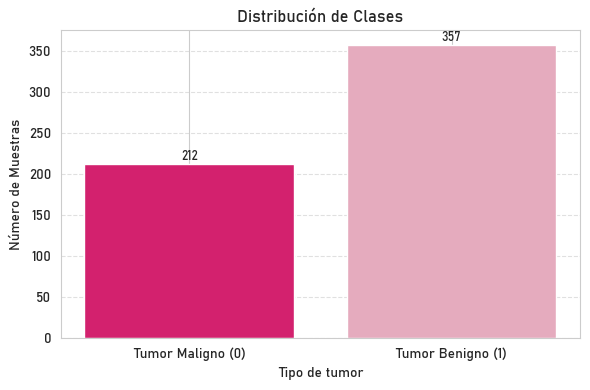

In [56]:
value_counts = data['target'].value_counts().sort_index()
labels = ['Tumor Maligno (0)', 'Tumor Benigno (1)']

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, value_counts, color=["#d3216e", "#e5abbe"])
plt.title('Distribución de Clases', fontsize=12)
plt.xlabel('Tipo de tumor', fontsize=10)
plt.ylabel('Número de Muestras', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Agregar etiquetas en las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


Al analizar la gráfica de la distribución de clases junto con el conteo de muestras, se observa un **desequilibrio moderado**: existen **357 casos de tumores benignos (1)** frente a **212 casos de tumores malignos (0)**. Aunque la diferencia no es extrema, este desbalance podría influir en el desempeño del modelo, especialmente en la capacidad para detectar correctamente los casos menos frecuentes (tumores malignos). 

### **Matriz de correlación: Variables Predictoras**

La **multicolinealidad** representa un problema en los modelos predictivos, ya que puede reducir la interpretabilidad y la estabilidad de los coeficientes asociados a las variables independientes. Para abordar este inconveniente, es necesario identificar y eliminar aquellos predictores que presentan alta correlación entre sí. Como primer paso para detectar posibles casos de multicolinealidad en nuestros datos, analizaremos la **matriz de correlación** entre las variables.


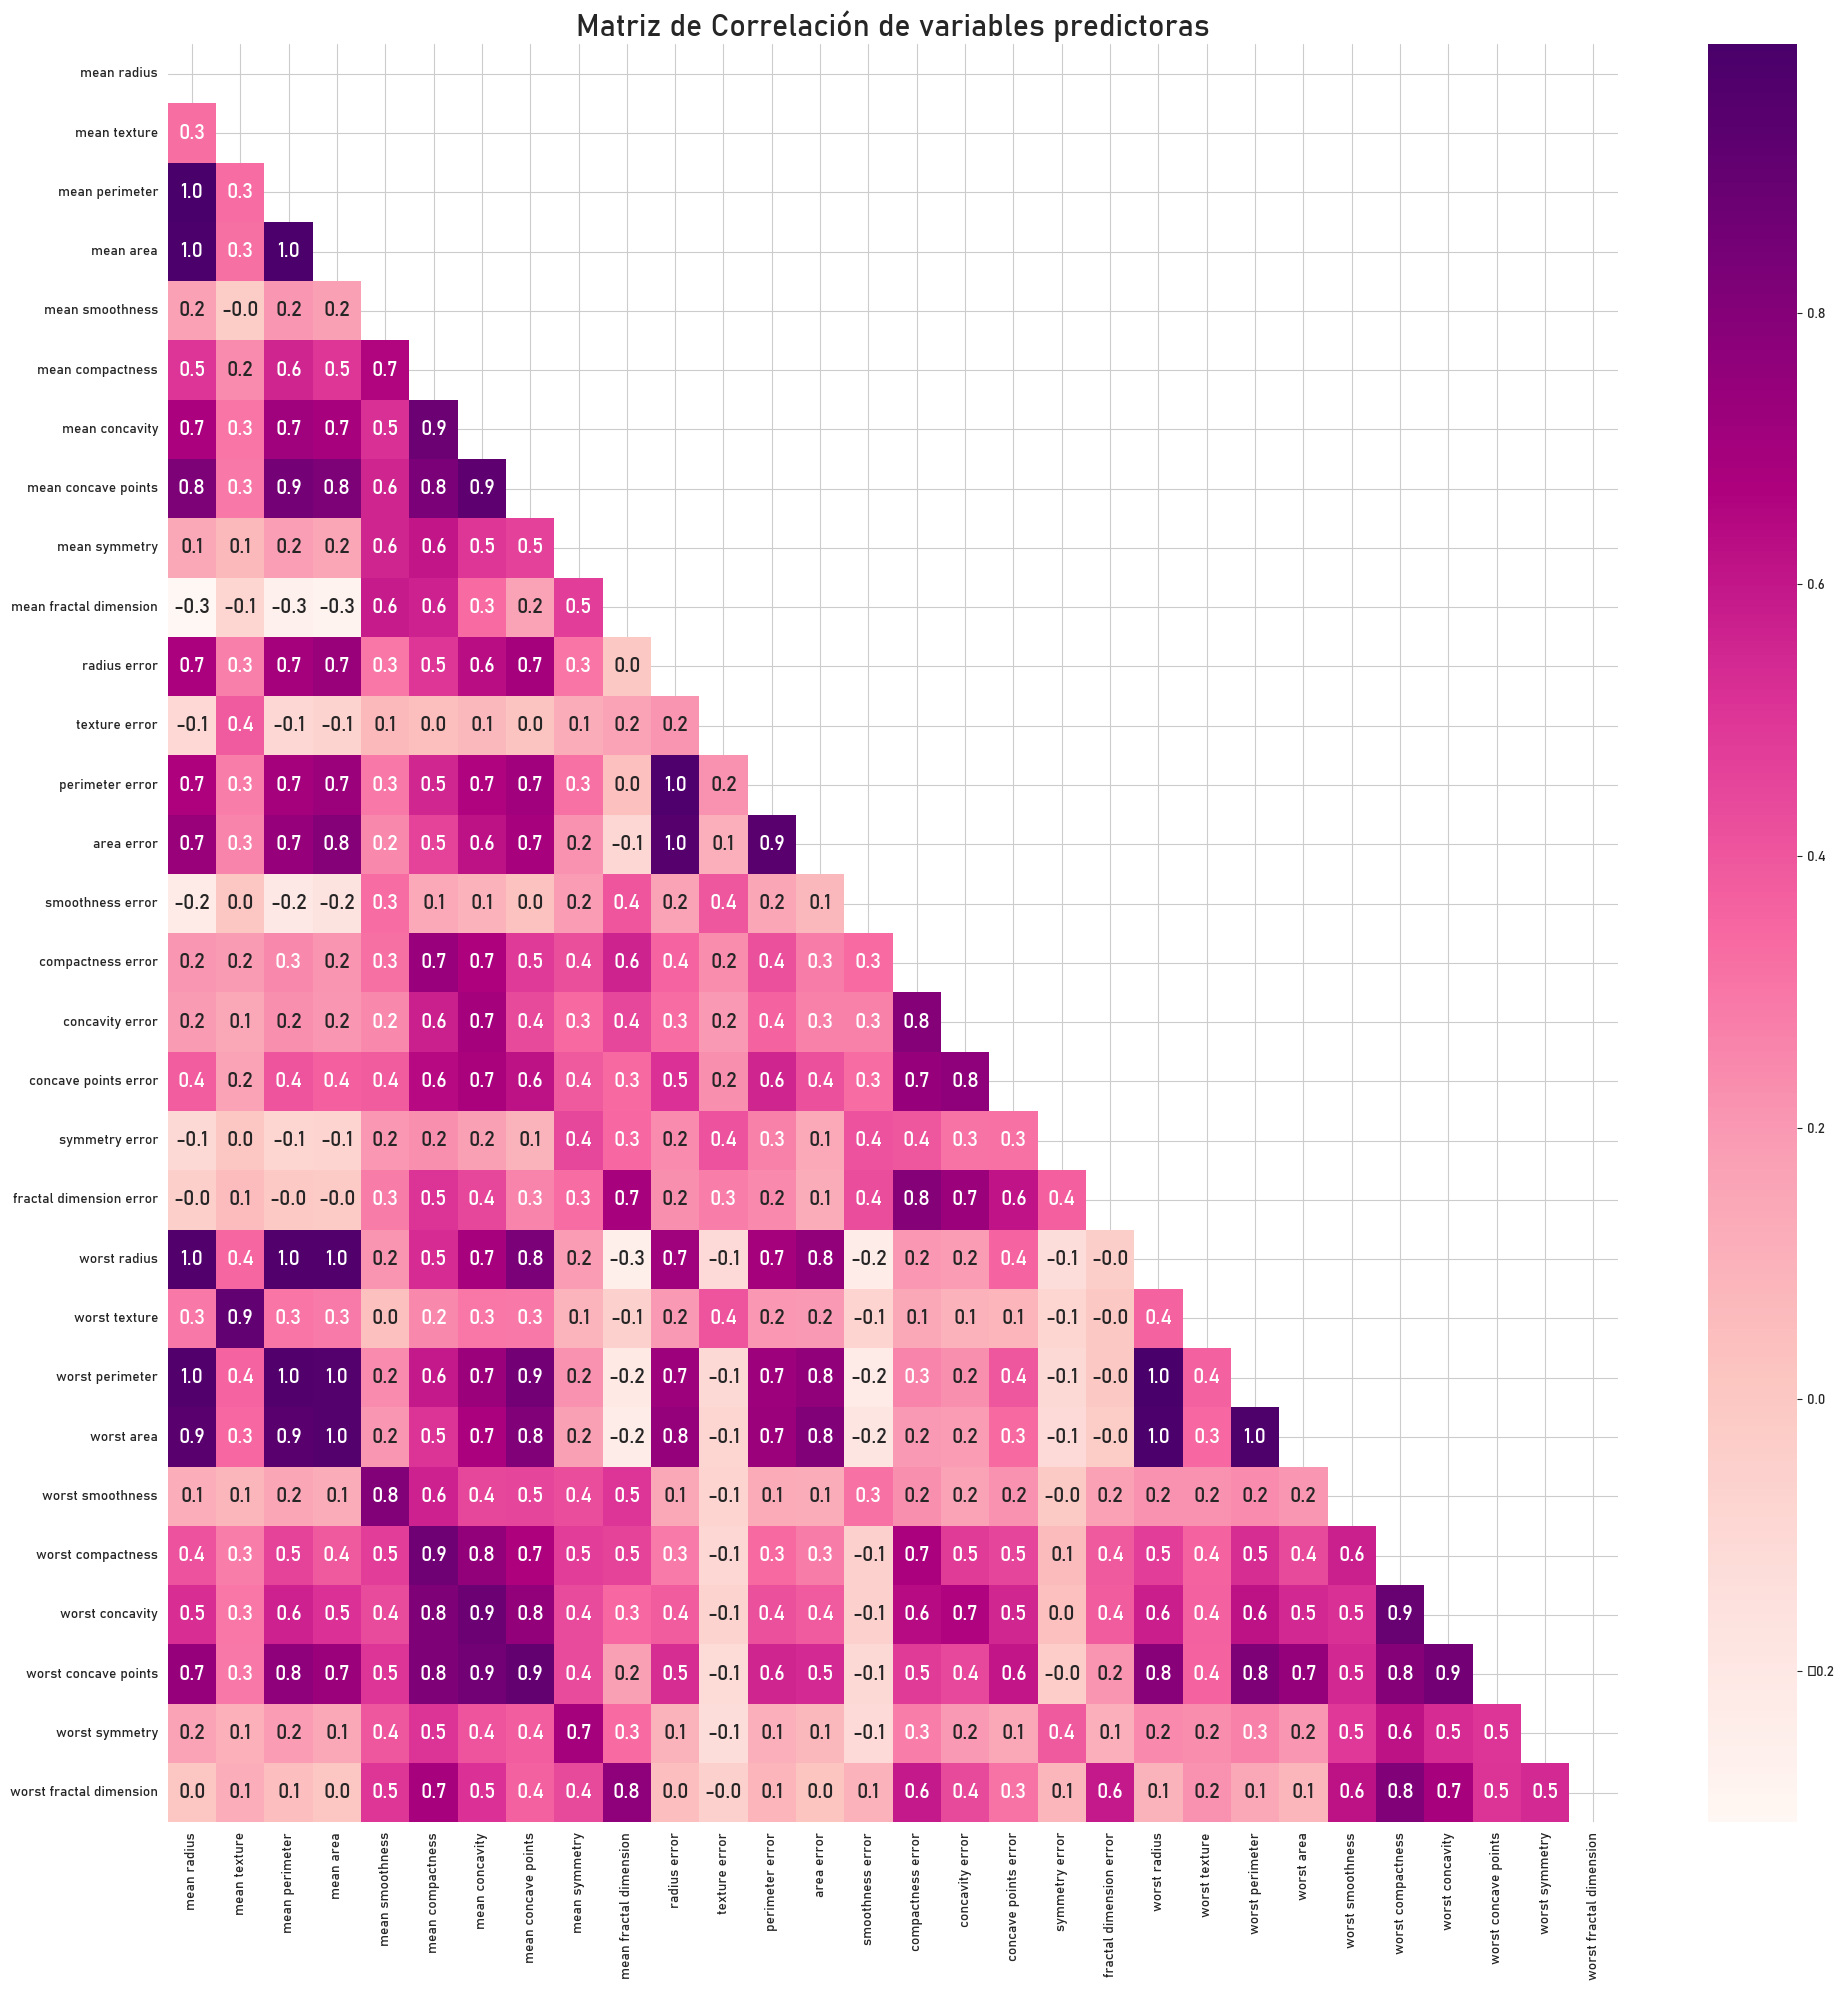

In [57]:
correlaciones = data.iloc[:, 1:].corr()

mascara_superior = np.zeros_like(correlaciones)
mascara_superior[np.triu_indices_from(mascara_superior)] = True

plt.figure(figsize=(20, 20))

sns.heatmap(correlaciones, mask=mascara_superior, cbar=True, fmt='.1f', annot=True, annot_kws={'size': 15}, cmap='RdPu')
plt.title('Matriz de Correlación de variables predictoras', fontsize=22)
plt.tight_layout()
plt.show()


La matriz de correlación muestra la relación entre las distintas variables predictoras del conjunto de datos. Se observan varios pares de variables con correlaciones muy altas (valores cercanos a **1.0**), lo cual indica una **alta redundancia de información** y sugiere la presencia de **multicolinealidad**. Por ejemplo, se evidencia una fuerte correlación entre `mean radius`, `mean perimeter` y `mean area`, así como entre `worst radius`, `worst perimeter` y `worst area`. Esta redundancia puede afectar negativamente la estabilidad de los coeficientes en modelos lineales. Por lo tanto, será necesario aplicar técnicas para mitigar la multicolinealidad.


## **Preprocesamiento**

### **Multicolinealidad de las variables: VIF**

Al observar la **matriz de correlación**, se evidencia la presencia de varias variables altamente correlacionadas entre sí, lo que confirma la existencia de **multicolinealidad**. Para cuantificar este fenómeno con mayor precisión, aplicaremos el **Factor de Inflación de la Varianza (VIF)**. Esta métrica evalúa qué tan fuertemente una variable independiente está correlacionada con el resto de variables independientes. En otras palabras, el VIF estima cuánto se ve inflada la varianza del coeficiente de una variable debido a la colinealidad con otras. Una puntuación alta de VIF indica que la variable puede ser explicada en gran medida por otras predictores, lo que puede comprometer la estabilidad y la interpretabilidad del modelo.


In [58]:
def VIF_calculation(X):
    """
    Calcula el Factor de Inflación de la Varianza (VIF) para cada variable independiente en el DataFrame X.
    
    Parámetros:
    X (pd.DataFrame): DataFrame que contiene únicamente las variables independientes (predictoras).
    
    Retorna:
    pd.DataFrame: Tabla con los nombres de las variables y sus respectivos valores de VIF, ordenados de mayor a menor.
    """

    # Crear un nuevo DataFrame vacío para guardar los resultados
    VIF = pd.DataFrame()

    # Guardar los nombres de las columnas en la primera columna del DataFrame de salida
    VIF["variable"] = X.columns

    # Calcular el VIF para cada columna del DataFrame X
    # El VIF indica cuánto se inflan las varianzas de los coeficientes debido a la multicolinealidad
    VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    # Ordenar los resultados de forma descendente por el valor del VIF
    VIF = VIF.sort_values('VIF', ascending=False).reset_index(drop=True)

    # Retornar el DataFrame con los resultados
    return VIF

In [59]:
def remove_multicollinearity(df, target_name, VIF_threshold):
    X = df.drop(target_name, axis=1)

    # Se calcula el VIF (Factor de Inflación de la Varianza) para todas las variables independientes
    VIF_mat = VIF_calculation(X)

    # Se toma el mayor valor de VIF (se asume que está en la primera fila ya ordenada)
    n_VIF = VIF_mat["VIF"][0]

    # Si no hay multicolinealidad significativa (el mayor VIF está por debajo del umbral), se imprime mensaje
    if (n_VIF <= VIF_threshold):
        print("There is no multicollinearity!")
    else:
        # Si existe multicolinealidad, se entra en un bucle
        while (n_VIF > VIF_threshold):
            # Se elimina la variable con el VIF más alto
            X = X.drop(VIF_mat["variable"][0], axis=1)

            # Se recalcula el VIF después de eliminar la variable
            VIF_mat = VIF_calculation(X)

            # Se actualiza el mayor VIF
            n_VIF = VIF_mat["VIF"][0]

    # Se muestra en pantalla la tabla final de VIF luego de eliminar las variables colineales
    display(VIF_mat)

    # Se retorna el conjunto de datos sin las variables con alta multicolinealidad
    return X


In [60]:
data_vif = remove_multicollinearity(data, "target", 10)

,variable,VIF
0,symmetry error,8.648328
1,smoothness error,8.347757
2,fractal dimension error,7.644681
3,texture error,7.103564
4,concavity error,6.666504
5,worst concavity,4.620458
6,area error,2.190762


Después de aplicar el análisis de **Factor de Inflación de la Varianza (VIF)** con un umbral de 10, se eliminaron las variables con multicolinealidad severa. El conjunto de datos resultante contiene ahora variables con valores de VIF inferiores al umbral, lo cual indica una multicolinealidad aceptable entre los predictores. Las variables restantes, como `symmetry error` (VIF ≈ 8.65), `smoothness error` (VIF ≈ 8.35) y `fractal dimension error` (VIF ≈ 7.64), presentan una correlación moderada con el resto, pero no lo suficientemente alta como para comprometer el modelo. En general, esta depuración mejora la estabilidad de los coeficientes y la interpretabilidad del modelo de regresión.


In [61]:
data_vif.head()

,texture error,area error,smoothness error,concavity error,symmetry error,fractal dimension error,worst concavity
0,0.9053,153.40,0.006399,0.05373,0.03003,0.006193,0.7119
1,0.7339,74.08,0.005225,0.01860,0.01389,0.003532,0.2416
2,0.7869,94.03,0.006150,0.03832,0.02250,0.004571,0.4504
3,1.1560,27.23,0.009110,0.05661,0.05963,0.009208,0.6869
4,0.7813,94.44,0.011490,0.05688,0.01756,0.005115,0.4000


Tras realizar el proceso de **preprocesamiento** y aplicar el análisis de multicolinealidad mediante **VIF**, el conjunto de datos final queda reducido a **7 variables predictoras**. 


## **Implementación de modelos**

### **Importante:**
- Nótese que al tratarse de un tema de salud crítico, es de vital importancia escoger la métrica más acertada para asegurarnos de dar las mejores estimaciones. Es por ello, que en este caso, decidimos trabajar con *`Recall`*. Esta métrica nos permitirá limitar los falsos negativos, es decir, aquellas observaciones que en realidad SI tienen cáncer pero fueron predichas como que NO tienen. 

- Para la construcción de cada modelo se usará pipelines, donde se especifica que primero se debe realizar el escalamiento de los datos mediante el método `MinMaxScaler()` y, posteriormente, ajustar el modelo de clasificación, que en este caso es `KNeighborsClassifier()` o `LogisticRegression()`. Se utiliza un `param_grid` para definir los hiperparámetros a evaluar, donde se especifica el número de vecinos del modelo y el peso que toma cada uno de ellos. Seguido a ello, se construye el esquema de validación cruzada mediante el método `StratifiedKFold()`. Finalmente, se aplica el método `GridSearchCV()` con cada uno de los argumentos correspondientes y tomando en cuenta la métrica más adecuada para este ejemplo, que en este caso es el `recall`.

### **Conjuntos de entrenamiento y test**

Inicialmente, se realiza la partición del conjunto de datos utilizando el método `train_test_split()`, configurando el parámetro `stratify` igual al conjunto de etiquetas (`stratify = y`). Esto garantiza que la proporción de clases se mantenga consistente tanto en el conjunto de entrenamiento como en el de prueba, asegurando una distribución equilibrada de las etiquetas en ambas divisiones. Además se fija un `random_state = 11`


In [62]:
X = data_vif
y = data['target']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 11) 

### **Modelo: *K-NN***

In [64]:
# Preprocesamiento: Escalación
# Clasificación: Modelo

pipeline_knn = Pipeline([('scaler', MinMaxScaler()), ('clasificador', KNeighborsClassifier())]) 

param_grid_knn = [{ 'clasificador__n_neighbors': range(5 , 50), # Número de vecinos del modelo
                   'clasificador__weights': ['uniform', 'distance']}] 

kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 11)

grid_met = GridSearchCV(pipeline_knn, param_grid_knn, cv = kf, scoring = 'recall')

In [65]:
grid_met.fit(X_train, y_train)
print("Mejores parámetros:", grid_met.best_params_)
print("Mejor Recall en conjunto de entrenamiento: ",grid_met.best_score_)
y_pred_knn = grid_met.predict(X_test)
recall = recall_score(y_test, y_pred_knn)
print('Mejor Recall en conjunto de test:', recall)

Mejores parámetros: {'clasificador__n_neighbors': 8, 'clasificador__weights': 'distance'}
Mejor Recall en conjunto de entrenamiento:  0.93277428371768
Mejor Recall en conjunto de test: 0.9555555555555556


### **Modelo: *Regresión Logística***

In [66]:
# MinMaxScaler: para normalizar nuestros datos entre 0 y 1

pipeline_rl = Pipeline([ ('scaler', MinMaxScaler()), ('clasificador', LogisticRegression())])

param_grid_lr = {'clasificador__C': [0.01, 0.1, 1, 10, 100, 1000]}

kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 11)

grid_rl = GridSearchCV(pipeline_rl, param_grid_lr, cv = kf, scoring = 'recall')

grid_rl.fit(X_train, y_train)
print("Mejor parámetro:", grid_rl.best_params_)
print("Mejor Recall en conjunto de entrenamiento:", grid_rl.best_score_)
y_pred_lr = grid_rl.predict(X_test)
recall_lr = recall_score(y_test, y_pred_lr)
print('Mejor Recall en conjunto de test:', recall_lr)

Mejor parámetro: {'clasificador__C': 0.01}
Mejor Recall en conjunto de entrenamiento: 1.0
Mejor Recall en conjunto de test: 1.0


## **Resultados**

### **Métricas**

In [71]:
# Se hacen las predicciones para poder comparar con las diferentes métricas
KYP = grid_met.predict(X_test)
LYP = grid_rl.predict(X_test)

# Evalua las predicciones en cada métrica con las etiquetas del test
tabla1 = {
    'Modelo': ['KNN', 'Regresión logística'],
    'Precision': [
        precision_score(y_test, KYP), # K-NN
        precision_score(y_test, LYP) # Regresión logística
    ],
    'Recall': [
        recall_score(y_test, KYP),
        recall_score(y_test, LYP)
    ],
    'F1 Score': [
        f1_score(y_test, KYP),
        f1_score(y_test, LYP)
    ],
    # En ROC AUC, No se tienen en cuenta las etiquetas sino las probabilidades
    'ROC AUC': [
        roc_auc_score(y_test, KYP), 
        roc_auc_score(y_test, LYP)  
    ]
}

cuadro1 = pd.DataFrame(tabla1).round(2)
cuadro1


,Modelo,Precision,Recall,F1 Score,ROC AUC
0,KNN,0.88,0.96,0.91,0.86
1,Regresión logística,0.63,1.00,0.77,0.50


### **Matrices de confusión**

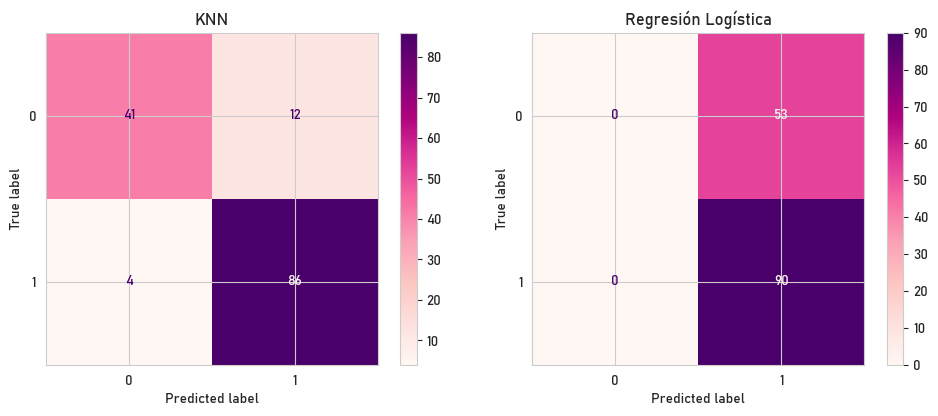

In [72]:
# Matrices de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_lr).plot(ax=axes[1], cmap='RdPu')
axes[1].set_title('Regresión Logística')
ConfusionMatrixDisplay(cm_knn).plot(ax=axes[0], cmap='RdPu')
axes[0].set_title('KNN')

plt.tight_layout()
plt.show()


### **Curvas AUC - ROC**

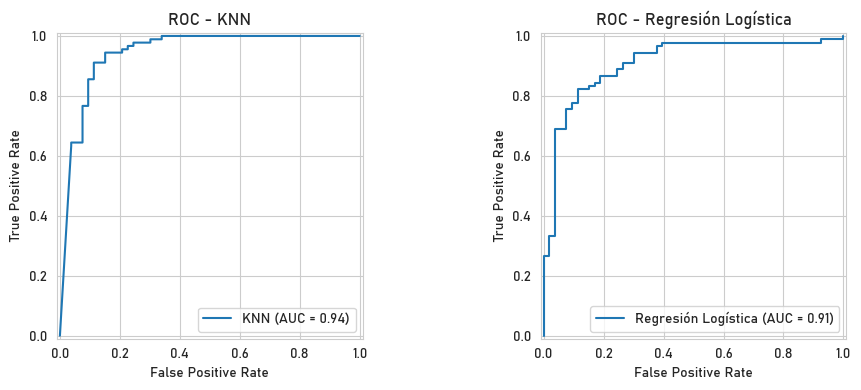

In [70]:
y_prob_lr = grid_rl.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

y_prob_knn = grid_met.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
roc_disp_lr = RocCurveDisplay(fpr=fpr_lr, tpr=tpr_lr, roc_auc=roc_auc_lr, estimator_name='Regresión Logística')
roc_disp_lr.plot(ax=axes[1])
axes[1].set_title('ROC - Regresión Logística')

roc_disp_knn = RocCurveDisplay(fpr=fpr_knn, tpr=tpr_knn, roc_auc=roc_auc_knn, estimator_name='KNN')
roc_disp_knn.plot(ax=axes[0])
axes[0].set_title('ROC - KNN')

plt.tight_layout()
plt.show()


### **Interpretaciones**

A partir del análisis de desempeño, el modelo **K-Nearest Neighbors (KNN)** demuestra un rendimiento superior al de **Regresión Logística**. Aunque ambos modelos obtienen una alta tasa de aciertos para la clase positiva (Benigno), KNN logra un equilibrio más efectivo entre precisión y recall, con un **F1 Score de 0.91** frente a 0.77 en regresión logística. Esto también se refleja en su **curva ROC**, donde KNN alcanza un **AUC de 0.94**, superando al AUC de 0.91 de la regresión logística.

Las **matrices de confusión** refuerzan esta diferencia: mientras que KNN clasifica correctamente tanto tumores benignos como malignos (solo 4 falsos negativos y 12 falsos positivos), la regresión logística falla completamente al clasificar tumores malignos, prediciendo todos los casos como benignos (100% de falsos positivos para la clase 0). Esto explica su recall de 1.00 pero una precisión baja (0.63), indicando que acierta mucho, pero también se equivoca bastante.

En resumen, KNN no solo presenta mejores métricas generales, sino que además mantiene un desempeño equilibrado y robusto en ambas clases, lo cual lo convierte en una opción claramente más confiable para este problema de clasificación.
